# A likelihood ratio for glass fragments

The last couple of weeks you have been learning about Python and data science, this week we will be showing you how you can use all this knowledge for creating a Likelihood Ratio (LR) system. In this notebook, we will be going over all the steps needed to get a well-calibrated LR system using machine learning. More specifically, we will be creating an **LR system for comparing glass fragments**.

In forensic glass analysis, most cases involve a comparison of glass samples to determine whether glass fragments on, say, a garment from a suspect originate from a certain glass source like a shattered crime scene window. By performing forensic glass comparisons, a suspect could be linked to a crime scene. For these studies the following hypotheses can be formulated:

*H<sub>p</sub>: the glass fragment found on the garment is from the window at the crime scene*

*H<sub>d</sub>: the glass fragment found on the garment is from another glass source*

To answer the question whether the glass fragment found on the garment is from the window at the crime scene, **the glass fragment that was found on the garment is compared to a glass fragment from the window at the crime scene**. A forensic expert makes a judgement about the likelihood of finding the observed similarities between the samples in light of the two hypotheses, resulting in a *verbal* LR. By using statistical or machine learning methods, we can actually quantify the likelihood of finding the observed similarities in light of the hypotheses. We try to model the following probabilities:

$$
P(E|H_p) = P(\text{similarity between glass fragments}|\text{the glass fragments are from the same source})
$$

$$
P(E|H_d) = P(\text{similarity between glass fragments}|\text{the glass fragments are from different sources})
$$

which we can then use to calculate an LR:

$$
LR=\frac{P(E|H_p)}{P(E|H_d)}
$$

To get the probabilities, we need to *teach* our model how similar measurements from two glass fragments from the same source are and how similar two glass samples from different sources are. To be able to learn this, the model needs to see examples, very similar to how we as humans learn things. In this notebook, we use a **forensic glass dataset** consisting of glass particles from different sources of crime scene glass (known glass source) from about 10 years of casework at the Netherlands Forensic Institute. For each glass fragment, the concentration of ten elements is measured using LA-ICPMS (a type of mass spectrometer). Three measurements are performed per glass fragment, so we can make pairs of glass fragments that originated from the same source and pairs of glass fragments that originated from different sources. We made this dataset publicly available on GitHub: https://github.com/NetherlandsForensicInstitute/elemental_composition_glass.

Let's first start by loading in the data and exploring it a bit!

## Dataset

First, we will load the data. We will be using the pandas library, you should already be familiar with this library after the previous tutorials. The glass data is available on GitHub as a *csv* file, so all we need to do is tell pandas where the csv file can be found and how the cells are separated:

In [1]:
!pip install lir==1.3.3 requests==2.32.5
import pandas as pd

# link to the publicly available data on GitHub
url_data = 'https://raw.githubusercontent.com/NetherlandsForensicInstitute/elemental_composition_glass/main/training.csv'
# Load the data as a pandas dataframe
dataset = pd.read_csv(url_data, delimiter=',')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.8/725.8 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found ex

We can use the `.info()` method for a pandas dataframe to get information about the dataset and the data types that are in it:

In [2]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1977 entries, 0 to 1976
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      1977 non-null   int64  
 1   Item    1977 non-null   int64  
 2   Piece   1977 non-null   int64  
 3   K39     1977 non-null   float64
 4   Ti49    1977 non-null   float64
 5   Mn55    1977 non-null   float64
 6   Rb85    1977 non-null   float64
 7   Sr88    1977 non-null   float64
 8   Zr90    1977 non-null   float64
 9   Ba137   1977 non-null   float64
 10  La139   1977 non-null   float64
 11  Ce140   1977 non-null   float64
 12  Pb208   1977 non-null   float64
dtypes: float64(10), int64(3)
memory usage: 200.9 KB


As can be seen, there are 13 columns for each measurement:

- id: a unique integer for each measurement
- Item: a unique integer for each glass object
- Piece: for each glass object, a unique integer representing the repeated measurements on this object
- K39, Ti49, Mn55, Rb85, Sr88, Zr90, Ba137, La139, Ce140, Pb208: the processed concentration of each element. The number behind the element in the column name specifies which isotope of the element was measured. The processed concentrations are all float numbers.

Furthermore, we see that there are 1977 entries, and every column has 1977 non-null values. In other words, there are no missing values.

Next, we have a look at the amount of data we have:

In [3]:
print("Number of measurements: ", dataset['id'].nunique())
print("Number of glass objects: ", dataset['Item'].nunique())
print("Maximum number of repeated measurements on one glass object: ", dataset['Piece'].nunique())

Number of measurements:  1977
Number of glass objects:  659
Maximum number of repeated measurements on one glass object:  3


Above you can see the number of glass objects (=distinct sources) and measurements.

Each row of the dataframe contains one measurement of a glass fragment with 10 measured elemental concentrations:


In [4]:
dataset.head()

,id,Item,Piece,K39,Ti49,Mn55,Rb85,Sr88,Zr90,Ba137,La139,Ce140,Pb208
0,1,1,1,2.901159,2.491670,2.154241,0.419956,1.738384,1.734640,1.662191,0.787460,0.949390,0.392697
1,2,1,2,2.925694,2.510800,2.170262,0.367356,1.719994,1.651666,1.671358,0.658011,0.949390,0.371068
2,3,1,3,2.926147,2.506140,2.159597,0.382017,1.707740,1.605413,1.655523,0.691081,0.931458,0.363612
3,4,2,1,3.314758,2.447018,1.814647,0.549003,1.987264,1.811575,1.913602,0.526339,0.705864,0.826723
4,5,2,2,3.327091,2.435956,1.835754,0.624282,1.954194,1.733999,1.903036,0.488551,0.695482,0.838219


To get a bit more feeling for the data, we can create a histogram of all measurements per element together. We can do this by using the `.hist()` method of the pandas dataframe class. In the hist method we can define the figure size (`figsize`) and the number of rows and columns for the figure (`layout`):

Histogram of all measured concentrations:


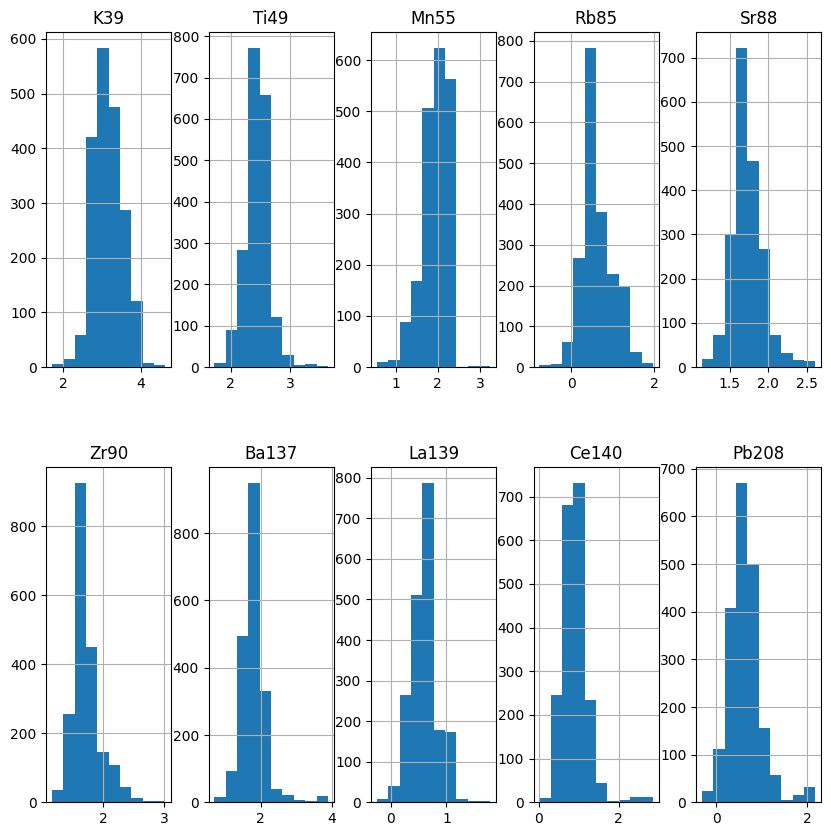

In [5]:
print("Histogram of all measured concentrations:")
# Create a list of columns in our dataframe for which we want to create histograms
measured_concentrations = ["K39", "Ti49", "Mn55", "Rb85", "Sr88", "Zr90", "Ba137", "La139", "Ce140", "Pb208"]
# create histograms of measured concentrations
dataset[measured_concentrations].hist(figsize=(10,10), layout=(2,5));

In the histograms, we see that there are no distinctive outliers, nice! We can continue with checking for duplicated entries.

In [6]:
# To check for duplicates, we use .duplicated()
import numpy as np
np.where(dataset.duplicated())

(array([], dtype=int64),)

The result is an empty array, meaning there are no duplicate values.

### Explore some more! (DIY)

Of course, a lot more data-exploration that can be done. Use the code-block below to do any additional exploratory research to get a good grasp of the data you're dealing with. To get inspiration for what to do here, you could go back to the notebook of week 2 of this course.

Diagram of all measured concentrations:


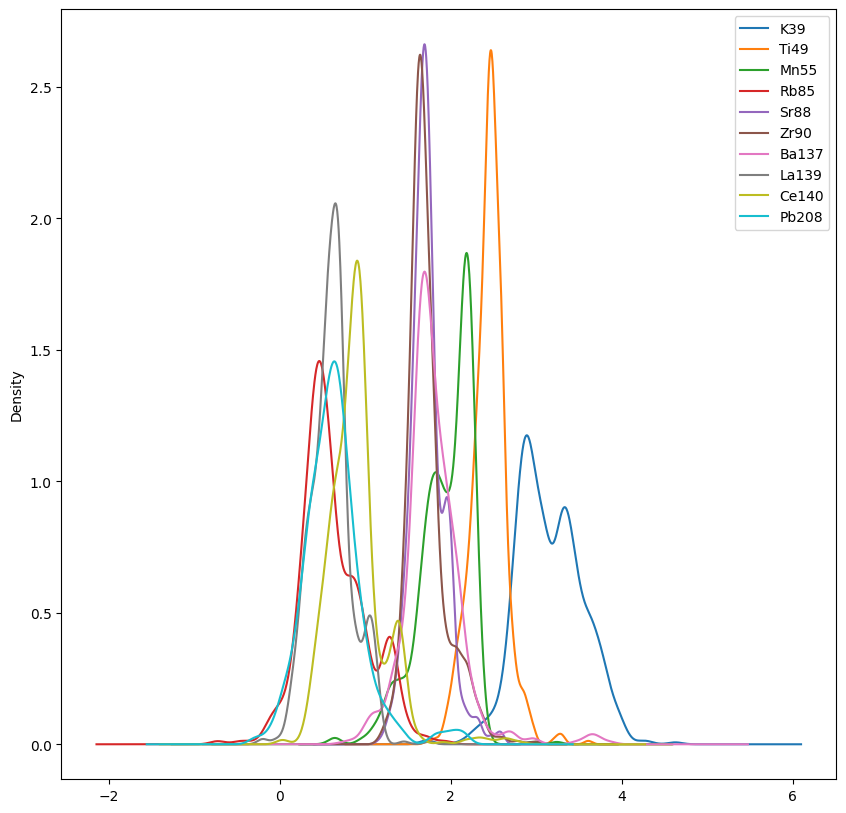

In [10]:
#### Any additional data exploration can be done here!
print("Diagram of all measured concentrations:")
# Create a list of columns in our dataframe for which we want to create histograms
measured_concentrations = ["K39", "Ti49", "Mn55", "Rb85", "Sr88", "Zr90", "Ba137", "La139", "Ce140", "Pb208"]
# create histograms of measured concentrations
dataset[measured_concentrations].plot.kde(figsize=(10,10), layout=(2,5));

## Machine Learning

Now that we have explored our data, we can start with creating our machine learning model. For building LR systems, we use [LiR](https://github.com/NetherlandsForensicInstitute/lir), a library developed in-house at NFI.

LiR heavily relies on machine learning functions from the [Scikit-learn](https://scikit-learn.org/) library, which is a library for doing machine learning in Python.

In machine learning, a lot of data processing has to be done. The library [*NumPy*](https://numpy.org/) is a very popular python library for multi-dimensional array and matrix processing. Therefore, we convert the data to numpy arrays. Furthermore, we create the variable `features` (the features) and `source_ids` (the labels).

In [ ]:
# We set apart our features and source_ids and save them as numpy arrays
features = dataset[measured_concentrations].to_numpy()
source_ids = dataset[['Item']].to_numpy()

To prepare for further processing, we will create a `FeatureData` object from LiR, which combines all information on the instances that is currently available.

A `FeatureData` object has the following attributes:

- `features`: a vector of numerical features;
- `source_ids`: a vector of source ids, if available (in our case: values identifying a glass fragment);
- `labels`: a vector of hypothesis labels (to be used later on, when we have same-source and different-source pairs).

See also the [documentation page](https://netherlandsforensicinstitute.github.io/lir/api/lir/lir.data.models.html#lir.data.models.FeatureData) on `FeatureData`.

In [ ]:
# combine the features and source_ids into a FeatureData object, as understood by LiR
from lir import FeatureData
all_data = FeatureData(features=features, source_ids=source_ids)

### Splitting the data

Before we start with any model development, we need to decide which part of the data will be used to **train**, **validate** and **test** the model that we develop. We use the **training set** to train our LR systems on and we use the **test set** to compare the performance of different LR systems and parameter settings. Since we use the test set for model selection, we might end up overfitting on this set. Therefore, we use another *unseen* set to get a honest estimate of the performance of the chosen system, this set is called the **validation set**.

In the code block below, we first split our data into two parts, 80% for train and test and 20% for validation. Then, we split again the first part into two parts, 80% for training and 20% for testing. For splitting the data, we use the `SourcesTrainTestSplit` function of LiR, which uses the `source_ids` to ensure that none of the sources will appear in both sets. In our case, the `source_ids` are the glass pieces, and by using `SourcesTrainTestSplit`, the repeated measurements of the same glass ('Item') are in the same split. If we don't do this, we will get an inflated estimate of model performance, because the same glass is used in training/testing and validating (albeit not the same measurements).

Let's split the data:

In [ ]:
from lir.data_strategies import SourcesTrainTestSplit

# First we split off 20% from the data for a hold-out validation set (grouped per glass particle)
# The class SourcesTrainTestSplit uses the `source_ids` to make sure none of the sources will appear in both sets
splitter = SourcesTrainTestSplit(test_size=.20, seed=1)
(training_validation_set, test_set), = splitter.apply(all_data) #These groups contain the 'Item' ID, see the code block above

# Then we split off 20% to use as a test set
(training_set, validation_set), = splitter.apply(training_validation_set)

### Creating pairs

In the previous step, we split the data in a test, train and validation set. This is great, but it is not yet enough to fit our machine learning model. We want to say if two measurements are from the same glass or not, so our training material should be *pairs* of two measurements at a time. A pair can be **same source** (H1) or **different source**.

Therefore, we pair the instances into a combined input vector for our machine learning model. LiR has the `InstancePairing` and `SourcePairing` to combine instances into pairs. We will use the `SourcePairing` method, which generates a single pair for each combination of sources. It returns a `PairedFeatureData` that has now the following attributes:
- `features`: a combined vector of the two instances;
- `source_ids`: a vector of the paired source ids (dimensions `(n, 2)`);
- `labels`: a vector of hypothesis labels (1 = same-source; 0 = different-source).

Before we create pairs for our data, let's understand a bit better what this function does to the data. Below, we have created for you a super small dataset, called `features_dummy`, with only 5 rows and 2 columns. It is accompanied by `source_ids_dummy`, which provides information on the sources, assuming that there are only 2 types of glass. Run the code-cell below to check these dummy data, and then the cell after for creating pairs to the dummy data:

In [ ]:
features_dummy = np.array([[0, 1], [0, 0], [4, 4], [4, 5], [0, 1]])
source_ids_dummy = np.array([['glass1'], ['glass1'], ['glass2'], ['glass2'], ['glass1']])
print(f'our dummy dataset:\n{features_dummy}')
print()
print(f'and the corresponding source_ids:\n{source_ids_dummy}')

In [ ]:
from lir.transform.pairing import SourcePairing

pairing = SourcePairing()

# now let's call create pairs and inspect the outcome
dummy_pairs = pairing.pair(FeatureData(features=features_dummy, source_ids=source_ids_dummy))
print(f'dummy_pairs.features =\n{dummy_pairs.features}')
print()
print(f'dummy_pairs.source_ids =\n{dummy_pairs.source_ids}')
print()
print(f'dummy_pairs.labels = {dummy_pairs.labels}')

As you can see, a pair is created for each combination of sources. In addition, we see that now we have 4 columns per pair, as each row in `dummy_pairs.features` contains the information of two original rows. With respect to the `dummy_pairs.labels`, we can see that we went from 'glass1' and 'glass2' to 0s and 1s (0 when two original rows came from different type of glass and 1 when they came from the same type of glass).

Now we can use the pairing function to create pairs of the instances in each set (this may take some time):

In [ ]:
training_pairs = pairing.pair(training_set)
test_pairs = pairing.pair(test_set)
validation_pairs = pairing.pair(validation_set)

Let's look at the shape of the pairs:

In [ ]:
training_pairs.features.shape

We see that our array has 2*10 columns. This is because we have pairs of 2 instances with 10 elemental concentrations each, i.e. the vector consists of the concentrations of both samples.

Now let's have a look at the number of same source and different source samples in our training dataset:

In [ ]:
print(f'Number of same source pairs: {sum(training_pairs.labels==1)}')
print(f'Number of different source pairs: {sum(training_pairs.labels==0)}')

As you can see, we have many more *different-source* pairs than *same-source* pairs. This can be problematic for training a machine learning model, as it might achieve the best performance by always guessing that a sample is different source. To prevent our model from overfitting on the different source class, we undersample the majority class (*different-source*). We aim at having the number of different source samples equal to the number of same source samples. We use `ratio_limit` argument of `SourcePairing` to randomly select *different-source* samples so that we end up having as many as same source samples:

In [ ]:
pairing = SourcePairing(ratio_limit=1)
training_pairs = pairing.pair(training_set)

If we now look at our data for a second time, we see that we now have an equal amount of same and different source samples:

In [ ]:
print(f'Number of same source pairs: {sum(training_pairs.labels==1)}')
print(f'Number of different source pairs: {sum(training_pairs.labels==0)}')

### Normalizing data

Normally, as a last step in preprocessing our data, we would like to normalize our data so that our features are on the same scale, this helps the machine learning model a lot. However, the current data has already been normalized, the elemental concentrations are on a 10-log basis, and are normalized to the element Si. Therefore, we don't have to worry about this in the current example; but remember that this is an important step in training your model.

Scikit-learn has a bunch of very useful preprocessors that can be used to normalize your data and provides good documentation on when to use which preprocessor: https://scikit-learn.org/stable/modules/preprocessing.html.

### Fit the classifier

In the previous steps we have prepared our data by subdividing the data into **train**, **test** and **validation** and by **pairing** glass samples to create our feature vectors and hypothesis labels. Great, so now we can use our data to fit our machine learning model. We will start by fitting a [Random Forest classifier](https://scikit-learn.org/stable/modules/ensemble.html#forest), which is basically an ensemble of decision trees with different random starting points for which the model takes a majority vote, hence the name Random Forest. At the end of the notebook, you can try out different models until you're happy with the results, if so, you can apply your model on the validation set and see whether you have a good system :)

Let's fit our classifier (we call it our scorer, later we will explain why):

If decision trees are not a familiar term for you, please have a look at the [scikit-learn documentation](https://scikit-learn.org/stable/modules/tree.html).

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# first we initialize a random forest instance
scorer = RandomForestClassifier(random_state=0)

# squash the training features into 2 dimensions
training_pairs = training_pairs.replace_as(FeatureData, features=training_pairs.features.reshape(-1, 20))

# then we call the fit method of the model to fit it to our data
scorer.fit(training_pairs.features, training_pairs.labels)

### Model predictions

Now we have fitted our model, we can use it to make predictions, let's first see how the model performs on our train data:

In [ ]:
# we can feed our model the train pairs to make predictions on these samples
train_predictions = scorer.predict(training_pairs.features)

# calculate the percentage of correct predictions
print(f'Percentage correctly predicted: {np.mean(train_predictions == training_pairs.labels)*100}%')

Holy moly, our model predicts everything correctly. Amazing, so are we done now? Well, actually, it is not impressive that our model has correctly predicted all the examples used for training. Let's see if the results are as impressive on the test data:

In [ ]:
# squash the test features into 2 dimensions
test_pairs = test_pairs.replace_as(FeatureData, features=test_pairs.features.reshape(-1, 20))

# we can feed our model the train pairs to make predictions on these samples
test_predictions = scorer.predict(test_pairs.features)
# the predictions are just 1s and 0s: indicating whether the model thinks the pair is same source or different source
print(test_predictions[:10])
# calculate the percentage of correct predictions
print(f'Percentage correctly predicted: {np.mean(test_predictions == test_pairs.labels)*100}%')

Pretty good! But not 100%, which is to be expected for yet unseen data. At least we know that our model has learned something and makes the correct predictions in about 90% of the cases. Now let's move to the next step, how do we use these model outputs to get LRs?

### From score to LR

In the previous part we have fitted a Random Forest model; but how do we go from these predictions to an LR?

To get to an LR we need two probabilities; however, our Random Forest model returns the predicted labels e.g. 1 or 0. Remember previously we said that a Random Forest takes a majority vote of a bunch of decision trees, where each tree predicts whether the sample is a same source sample or a different source sample. We can ask the model to return the percentage of trees that predicted *same source* by calling the `predict_proba` method of the model instead of predict:

In [ ]:
# calculate scores
scores = scorer.predict_proba(test_pairs.features)

print('The first five predictions of the model:')
print(scores[:5])

Now we have an array with two columns, the first column giving us the percentage of trees that voted different source and the second column gives us the percentage of trees that voted same source. We could take these percentages directly and interpret them as probabilities and use them to calculate LRs:

In [ ]:
from lir import LLRData, plotting

# save the scores for Hp and Hd as our probabilities
P_Hp_test = scores[:, 1]
P_Hd_test = scores[:, 0]

# now divide these scores to get LRs
test_lrs = P_Hp_test/P_Hd_test

# we convert the LRs to log-LRs and store them as an LLRData object
# it is usually more convenient to work with LLRs (log-LR values) rather than with LR values
# documentation on LLRData, see: https://netherlandsforensicinstitute.github.io/lir/api/lir/lir.data.models.html#lir.data.models.LLRData
with np.errstate(divide='ignore'):
    test_llrs_uncalibrated = LLRData(features=np.log10(test_lrs), labels=test_pairs.labels)

# histogram for uncalibrated LRs
with plotting.show() as ax:
    ax.lr_histogram(test_llrs_uncalibrated, bins=np.arange(-2, 2, .25))

Great, now we have some sort of LRs, so are we done, right? Well not exactly, we have interpreted the output of the machine learning model as probabilities now; but in reality, these scores do not necessarily behave like probabilities. The focus of a machine learning model is on creating the optional boundary between the classes, which does not always result in probabilistic statements. Therefore we call these output values a score and not a probability. To interpret these scores as probabilities, we need to know whether they behave like probabilities: so we check whether the scores are *calibrated*.

### Calibration

One important aspect of an LR system is whether it is well calibrated: empirical frequencies should correspond to the probabilistic statement. To illustrate this concept, imagine we have a model that predicts whether it is going to rain tomorrow. This model is well-calibrated when in 80% of the cases where the model predicts a 0.8 probability for it to rain, it indeed rains. However, when it only rains on 50% of those days, we call the system ill-calibrated. A system that is not well calibrated can lead to LR statements that are too strong or too weak or even biased in the direction of one of the two hypotheses.

Let's check whether the scores that are returned by our model behaves like a well-calibrated probability. To do this, we can use the calibration-curve which is included in the Scikit-learn package (Scikit-learn also provides some [really nice documentation](https://scikit-learn.org/stable/modules/calibration.html) on the topic of calibration). The calibration-curve predicts the probabilities for the positive class with the provided scorer, labels, and features. The predictions of the model are binned and for each bin the mean predicted probability is calibrated (x-axis), this is then compared to the fraction of positive labels for that bin (y-axis). For a well calibrated system, we would expect that each bin is on the line through the origin as this would mean that the probabilistic statement correspond to the empirical frequencies. For our weather example, this would mean that with a mean predicted probability for a bin of 0.8 the fraction of positives should also be close to 0.8; if the fraction of positives is 0.5 (rain on 50% of the days) then the point will be below the line through the origin and the system is thus ill-calibrated.


Below we create a calibration-curve:

In [ ]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

# for the calibration curve we need the probabilities P_Hp and the labels
disp= CalibrationDisplay.from_estimator(scorer, test_pairs.features, test_pairs.labels, n_bins=5)

# we will move the legend so it is not clashing with the line
plt.legend(loc='upper center')

As you can see in the figure above, the predicted probabilities do not correspond to the empirical frequencies. The probabilities look like they are being underestimated by the model. So what can we do about this? Well, we can actually use a second model to shift these scores, so they behave like probabilities. We call such a model a calibrator. We will use the [Likelihood Ratio Library (LIR)](https://github.com/NetherlandsForensicInstitute/lir) for that, a package that is being developed by the NFI and is publicly available on GitHub. LIR contains a collection of scripts to aid calibration, calculation, and evaluation of Likelihood Ratios. LIR has a calibration module with calibrator classes, these calibrators map a score to a calibrated LR. It does this by internally fitting a mapping function on the scores (uncalibrated probabilities) and the labels to get calibrated probabilities, then these calibrated probabilities are used to calculate LRs. LIR also includes the cost log-likelihood ratio (Cllr) which is a performance metric for LR systems. The Cllr measures how well-calibrated a system is and how well it discriminates, the closer it is to 0 the better, when it's 1 the system is not providing any information and when the Cllr is above 1 the system is providing misleading information.

Let's first calculate the Cllr of our uncalibrated system:

In [ ]:
from lir.metrics import cllr
from lir import LLRData

print(f'The Cllr for our uncalibrated system: {cllr(test_llrs_uncalibrated)}')

Let's now try whether we can improve the system by applying calibration. We will be using the `LogitCalibrator` of the calibration module of LIR for this, this calibrator uses logistic regression as a mapping function:

In [ ]:
from lir.algorithms.logistic_regression import LogitCalibrator
from lir.util import probability_to_logodds

# 1: we calculate the scores on the train data
P_Hp_train = scorer.predict_proba(training_pairs.features)[:, 1]
llrs_train_uncalibrated = probability_to_logodds(P_Hp_train)

# 2: we make a calibration instance
calibrator = LogitCalibrator()

# 3: fit the calibrator
calibrator.fit(FeatureData(features=llrs_train_uncalibrated, labels=training_pairs.labels))

# 4: we use the calibrator to calibrate our uncalibrated scores
test_llrs_calibrated = calibrator.apply(test_llrs_uncalibrated)

# plot a histogram to get a first impression of the output LLRs
with plotting.show() as ax:
    ax.lr_histogram(test_llrs_calibrated, bins=np.arange(-5, 3, .25))

Let's see what the Cllr is for our calibrated results:

In [ ]:
# Note that when printing the Cllr for the uncalibrated LRs, we needed to convert the data to an LLRData object first.
# This time we don't need to do that, because that object is what calibrator.apply outputs.
print(f'The Cllr for our calibrated system: {cllr(test_llrs_calibrated)}')

As you can see our system improved quite a bit after calibration. We can see how much the system improved by calibrating with so-called PAV-figures. These figures show on the y-axis the LRs if they have been calibrated perfectly and on the x-axis the LRs that are returned by our system. Like the calibration-curve, you want the datapoints to be on the line through the origin, meaning the LRs have been perfectly calibrated.

Below the PAV-figures for our calibrated and uncalibrated LRs created with the LIR plotting module:

In [ ]:
from lir import plotting

# PAV for uncalibrated LRs
with plotting.show() as ax:
    ax.pav(test_llrs_uncalibrated)
    ax.set_xlabel('Scores / Uncalibrated log10 LRs')
    ax.set_ylabel('Perfect calibration')
    ax.title('PAV figure for uncalibrated Log10 LRs')

# PAV for calibrated LRs
with plotting.show() as ax:
    ax.pav(test_llrs_calibrated)
    ax.set_xlabel('Calibrated log10 LRs')
    ax.set_ylabel('Perfect calibration')
    ax.title('PAV figure for calibrated log10 LRs')

As can be seen above, the calibrated LRs are much closer to the grey line through the origin (perfect calibration) than the uncalibrated LRs, showing that the calibration indeed improved the system.

### Wrapping up

Most LR systems consists of several components that work together. A [pipeline](https://netherlandsforensicinstitute.github.io/lir/api/lir/lir.transform.pipeline.html#lir.transform.pipeline.Pipeline) object helps keeping things tidy.

In [ ]:
from lir.transform.pipeline import Pipeline

# construct the pipeline
pipeline = Pipeline(steps=[
    # include the estimator that yields psudo-probabilities ("scores")
    ('estimator', RandomForestClassifier(random_state=0)),

    # include a function to convert the psudo-probabilities to a pseudo-LLR
    ('probability_to_odds_function', probability_to_logodds),

    # include a calibration method to get calibrated LLRs
    ('calibrator', LogitCalibrator()),
])

# fit the pipeline on the training data
pipeline.fit(training_pairs)

# calculate LLRs for the test set
pipeline_llrs_calibrated = pipeline.apply(test_pairs)

# calculate the CLLR (check the result is identical to the previously calibrated LLRs!)
print(f'the Cllr as calculated with the pipeline is {cllr(pipeline_llrs_calibrated)}')

## Compare models and validate (DIY)

So we have shown that the random forest model with logistic calibrator works really well on the test dataset; but maybe there is another model that leads to a better LR system. A model that has won a lot of [*Kaggle*](https://www.kaggle.com/) competitions, data science contests, is the gradient boosted trees model (XGB). This model, like the random forest model, combines a bunch of decision trees (weak learners) to get a stronger model (strong learner). Let's see whether we can get a better LR system by using this model!

Now it's your turn to fit create the LR system! Try to create an LR system with the XGB model. Follow the steps as we explained earlier, so first fit the XGB model on the train data and calculate LRs. If you don't know how to do this, go back in the notebook. If you are happy with the model and results, you can validate your model at the end of this notebook on the validation set.

### 1. Fit XGB model and calculate LRs:

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# fit the model
scorer = None

# calculate scores
scores = None

# calculate uncalibrated LRs
uncalibrated_LRs = None

### 2. Check performance of uncalibrated system

Calculate the Cllr of this system and create any additional figures or metrics to get a good idea of the performance of the system.

In [ ]:
### calculate Cllr

### any additional figures or metrics

### 3. Add calibrator

Check whether the system can be improved by adding a calibrator:

In [ ]:
# fit the calibrator
calibrator = None

# calculate calibrated LRs
calibrated_LRs = None

### 4. Check performance of calibrated system

Calculate the Cllr of this system and create any additional figures or metrics to get a good idea of the performance of the system.

In [ ]:
### calculate Cllr

### any additional figures or metrics


### 5. Choose best model

You should have created four LR systems by now and evaluated the performance on the test data. You tried a random forest and XGB as scorers for the LR system, either with or without calibration. Which model do you think is the best choice to validate on the validation data, and why?

#### Your answer:
.......



### 6. Apply chosen LR system to validation data

Great, so you chose a LR system, that means there is only one step left to take: apply the chosen system to the validation (holdout) data. Use the code-block below to do this:


In [ ]:
#### Your answer here:

Now evaluate the performance of the chosen LR-system in the code-block below:

In [ ]:
### calculate Cllr

### any additional figures or metrics

What do you conclude, are you happy with the results?

#### Your answer:
....

## Kaggle Challenge

Do you want to put your data science skills to the test? See if you can implement your own model that predicts poisonous mushrooms in the Kaggle challenge: https://www.kaggle.com/t/3fb3213893214f28825b0f8848e471c9